# Challenge 1


Datasource: @inproceedings{gao2012exploring,
     title={Exploring social-historical ties on location-based social networks},
     author={Gao, Huiji and Tang, Jiliang and Liu, Huan},
     booktitle={Proceedings of the 6th International AAAI Conference on Weblogs and Social Media},
     year={2012}
}

- **Data**: `FS.csv` (avaliable in Google Drive - under folder LabFive)

1. Read the FS network dataset.
2. Describe using the basic functions of the graph's size. Explore nodes and edges. Provide how many nodes and edges are present in the network.
3. The dataset generates a graph of 639.014 nodes, so it is massive and you won't see anything meaningful if you try to plot it. So you need to create a subset using the **degree centrality** to find out find the top 4 of the most important nodes, and use them to create a subset of the original network. 
4. Extract the degree centrality values and convert them into a list. Then, plot a histogram to visualize the distribution of node degrees in the original network.
5. Create a plot for the subset created.
6. Now calculate another relevant measure of the network -- **betweenness centrality**. Plot the betweenness centrality distribution of the subset you created. Tip: Same steps from the previous step, but use `nx.betweenness_centrality()`
7. Plot the Matrix, Arc and Circos from the subset.

In [1]:
import networkx as nx
import pandas as pd

df = pd.read_csv('data/fs.csv')

G = nx.from_pandas_edgelist(df, source='source', target='target')

In [2]:
#filtering a subset of nodes to only get the most important ones

In this case, I was not able to describe the basic functions of the network's size with the full network since the dataset was too large, so I only explored a small subset of 15, and 4 nodes respectively.

In [3]:
#describing and exploring the graph's size
print(len(G.nodes)) #exploring the number of nodes in the graph
print(len(G.edges)) #exploring the number of edges in the graph

639014
3214986


In [4]:
print(type(G.nodes())) #exploring the datatype of our nodes
print(type(G.edges())) #exploring the datatype of our edges

<class 'networkx.classes.reportviews.NodeView'>
<class 'networkx.classes.reportviews.EdgeView'>


In [5]:
print(list(G.edges(data=True))[0]) #reading the attributes associated with the first elements of the edges list
print(list(G.nodes(data=True))[0]) #reading the attributes associated with the first elements of the nodes list

(34802, 0, {})
(34802, {})


In [6]:
print(type(list(G.edges(data=True))[-1][2])) #data type of edges
print(type(list(G.nodes(data=True)))) #data type of nodes

<class 'dict'>
<class 'list'>


In [7]:
import networkx as nx

#calculating degree centrality of our nodes in G
degree_centrality = nx.degree_centrality(G)

# removing nodes with zero degree centrality and sorting them in a descending order
sorted_centrality = sorted(
    [(node, centrality) for node, centrality in degree_centrality.items() if centrality > 0],
    key=lambda item: item[1],
    reverse=True
)

#printing only the top 4 nodes - with the highest degree centrality values 
for node, _ in sorted_centrality[:4]:
    print(node)

106223
89302
76517
66999


In [8]:
#extracting the degree centrality values and converting them into a list, to eliminate 
edges_from_G=G.edges([106223, 89302, 76517, 66999], data=True) #keeping only the edges for our four nodes of interest

In [9]:
#creating an empty graph 
G_sub = nx.DiGraph()
len(G_sub)

0

In [10]:
#adding the list from the subset of nodes
G_sub.add_edges_from(edges_from_G) 
len(G_sub)

106923

In [11]:
#describing and exploring the subset's size
print(len(G_sub.nodes)) #exploring the number of nodes in the subset
print(len(G_sub.edges)) #exploring the number of edges in the subset

106923
245929


In [12]:
print(type(G_sub.nodes())) #exploring the datatype of our subset
print(type(G_sub.edges())) #exploring the datatype of our subset

<class 'networkx.classes.reportviews.NodeView'>
<class 'networkx.classes.reportviews.OutEdgeView'>


In [13]:
print(list(G_sub.edges(data=True))[0]) #reading the attributes associated with the first elements of the edges subset
print(list(G_sub.nodes(data=True))[0]) #reading the attributes associated with the first elements of the nodes subset

(106223, 0, {})
(106223, {})


In [14]:
print(type(list(G_sub.edges(data=True))[-1][2])) #data type of edges in subset
print(type(list(G_sub.nodes(data=True)))) #data type of nodes in subset

<class 'dict'>
<class 'list'>


In [15]:
#can always pick random 4 ones that have at least twenty connections for the circos arcos plot

In [16]:
#plotting a histogram to visualise the degree centrality of nodes in the original network
#importing our libraries for visualisation
import matplotlib.pyplot as plt
import networkx as nx

In [17]:
#getting degree centrality for our subset
degree_centrality_subset = nx.degree_centrality(G_sub)

In [ ]:
degree_centrality_subset

In [19]:
centrality_values = [centrality for centrality in degree_centrality_subset.values() if centrality > 0]

In [20]:
test_df = pd.DataFrame(centrality_values, columns=['central_values'])

array([[<Axes: title={'center': 'central_values'}>]], dtype=object)

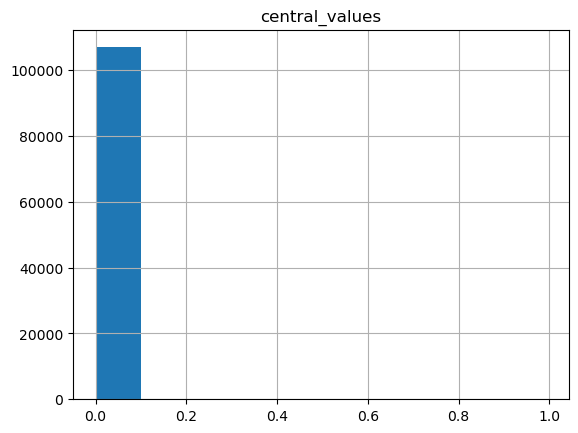

In [21]:
test_df.hist()

In [ ]:
# just a fancy plot for each node to plot the degree centrality
for node, centrality in degree_centrality_subset.items():
    print(f"Node {node}: Degree Centrality = {centrality:.3f}")

In [ ]:
# plot the graph
pos = nx.spring_layout(G_sub)
nx.draw(G_sub, pos, with_labels=True, node_size=700, node_color='skyblue')
plt.title('Graph G Subset with Degree Centrality')
plt.show()

In [ ]:
#calculating another relevant measure of the network - betweenness centrality 
betweenness_centrality = nx.betweenness_centrality(G_sub)

for node, centrality in betweenness_centrality.items():
    print(f"Node {node}: Betweenness Centrality = {centrality:.3f}")

#plotting the betweenness centrality of the subset we created 

In [ ]:
#plotting the matrix
import nxviz as nv
nv.MatrixPlot(G_sub)
plt.show()

In [ ]:
#plotting the arc
a = nv.ArcPlot(G_sub)
plt.show()

In [ ]:
#plotting the circos 
nv.CircosPlot(G_sub)
plt.show()